In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/placement.csv")

In [ ]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


<Axes: ylabel='cgpa'>

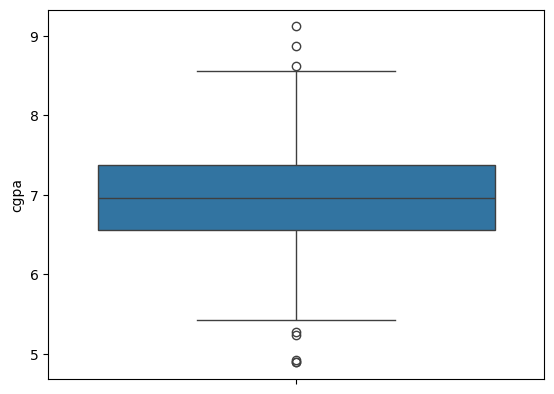

In [ ]:
import seaborn as sbn
sbn.boxplot(df['cgpa'])

<Axes: ylabel='placement_exam_marks'>

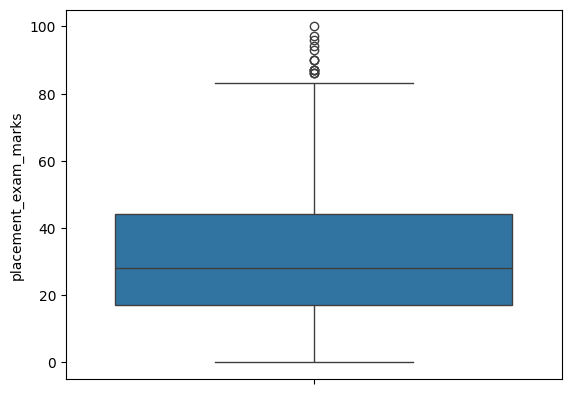

In [ ]:
sbn.boxplot(df['placement_exam_marks'])

In [ ]:
#data contains outliers
#now found which method we have to use


<ipython-input-70-6db43de929df>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(df['cgpa'])     #gaussian curve - use z-score


<Axes: xlabel='cgpa', ylabel='Density'>

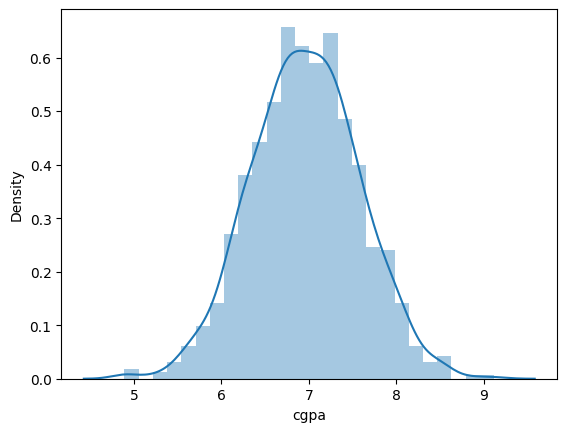

In [ ]:
sbn.distplot(df['cgpa'])     #gaussian curve - use z-score

<ipython-input-71-30c0509dfbb0>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(df['placement_exam_marks'])   #left skewed - use quantile


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

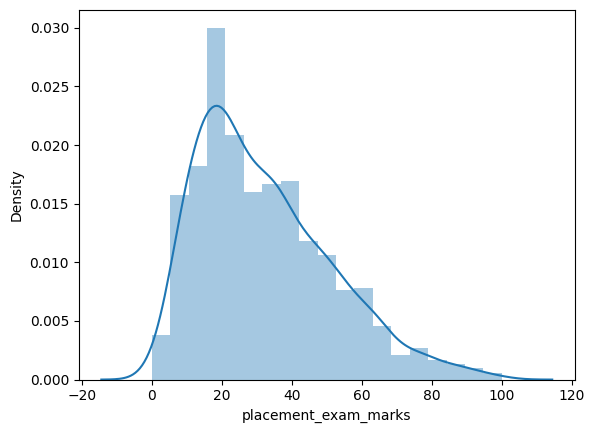

In [ ]:
sbn.distplot(df['placement_exam_marks'])   #left skewed - use quantile

In [ ]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [ ]:
df.shape

(1000, 3)

Applying z-score on cgpa

In [ ]:
max = df['cgpa'].mean()+3*df['cgpa'].std()   #8.808933625397168
min = df['cgpa'].mean()-3*df['cgpa'].std()   #5.113546374602832


In [ ]:
df[(df['cgpa']<min) | (df['cgpa']>max)]    #outliers

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [ ]:
#now detect whether we have to use capping , trimming , discritization

#if outliers>0.5% then capping otherwise trimming

In [ ]:
#capping
import numpy as np


df['cgpa'] = np.where(df['cgpa']>max,max,(np.where(df['cgpa']<min,min,df['cgpa'])))
df

,cgpa,placement_exam_marks,placed
0,7.190000,26.0,1
1,7.460000,38.0,1
2,7.540000,40.0,1
3,6.420000,8.0,1
4,7.230000,17.0,0
...,...,...,...
995,8.808934,44.0,1
996,8.808934,65.0,1
997,5.113546,34.0,0
998,8.620000,46.0,1


<ipython-input-78-07b409968ce1>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(df['cgpa'])  #5.11 - 8.88


<Axes: xlabel='cgpa', ylabel='Density'>

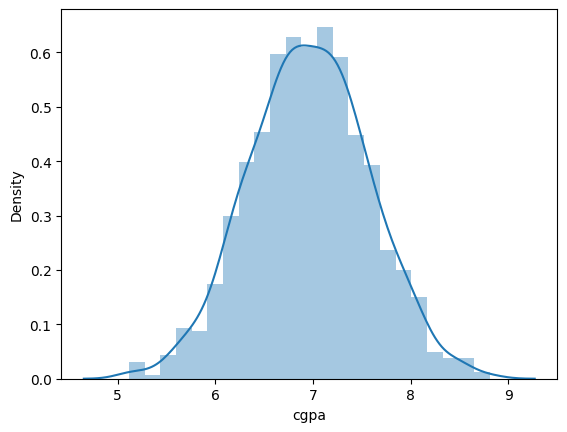

In [ ]:
#sbn.boxplot(df['cgpa'])
sbn.distplot(df['cgpa'])  #5.11 - 8.88

In [ ]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961499,32.225000,0.489000
std,0.612688,19.130822,0.500129
min,5.113546,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,8.808934,100.000000,1.000000


In [ ]:
#trimming

df_trimmed = df[(df['cgpa']<max) & (df['cgpa']>min)]
df_trimmed

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


<ipython-input-81-d93cbffcdf13>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(df_trimmed['cgpa'])    #5.11-8.88


<Axes: xlabel='cgpa', ylabel='Density'>

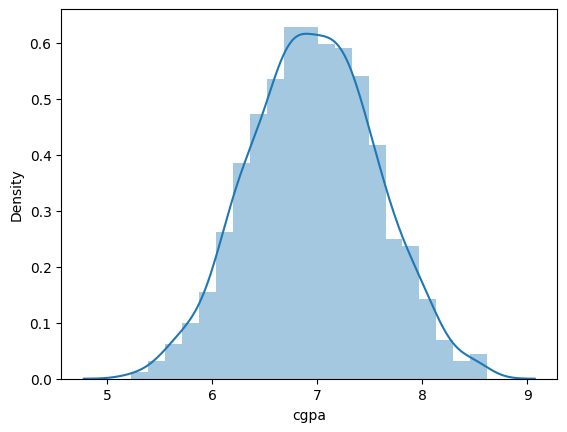

In [ ]:
#sbn.boxplot(df_trimmed['cgpa'])
sbn.distplot(df_trimmed['cgpa'])    #5.11-8.88

In [ ]:
df_trimmed.shape

(995, 3)

In [ ]:
#using z-score (another approach)

In [ ]:
df['z-score']=(df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()

In [ ]:
df_zscore = df[(df['z-score']<3) & (df['z-score']>-3)]
df_zscore

,cgpa,placement_exam_marks,placed,z-score
0,7.19,26.0,1,0.372949
1,7.46,38.0,1,0.813630
2,7.54,40.0,1,0.944202
3,6.42,8.0,1,-0.883807
4,7.23,17.0,0,0.438235
...,...,...,...,...
991,7.04,57.0,0,0.128126
992,6.26,12.0,0,-1.144952
993,6.73,21.0,1,-0.377841
994,6.48,63.0,0,-0.785878


In [ ]:
df

,cgpa,placement_exam_marks,placed,z-score
0,7.190000,26.0,1,0.372949
1,7.460000,38.0,1,0.813630
2,7.540000,40.0,1,0.944202
3,6.420000,8.0,1,-0.883807
4,7.230000,17.0,0,0.438235
...,...,...,...,...
995,8.808934,44.0,1,3.015293
996,8.808934,65.0,1,3.015293
997,5.113546,34.0,0,-3.016137
998,8.620000,46.0,1,2.706925


Applying quantile method for placement_exam_marks

<Axes: ylabel='placement_exam_marks'>

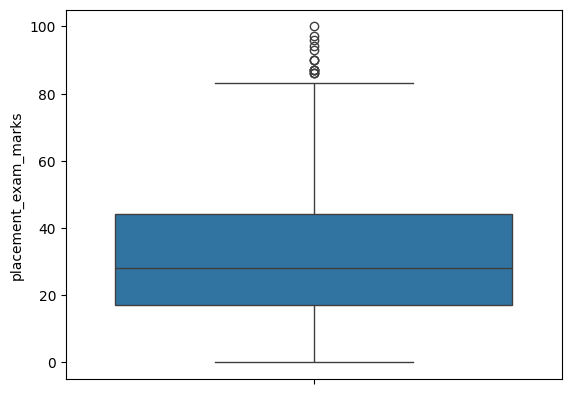

In [ ]:
sbn.boxplot(df['placement_exam_marks'])

In [ ]:
df_2 = pd.read_csv("/content/placement.csv")
df_2

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [ ]:
q1 = df_2['placement_exam_marks'].quantile(0.25)
q3 = df_2['placement_exam_marks'].quantile(0.75)
iqr = q3-q1

In [ ]:
max_range = q3+1.5*iqr    # 84.5
min_range = q1-1.5*iqr   #-23.5

-23.5

In [ ]:
#outliers

df_2[(df_2['placement_exam_marks']<min_range) | (df_2['placement_exam_marks']>max_range)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [ ]:
#Trimming


df_quantile = df_2[(df_2['placement_exam_marks']>min_range) & (df_2['placement_exam_marks']<max_range)]

In [ ]:
df_quantile

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


<Axes: ylabel='placement_exam_marks'>

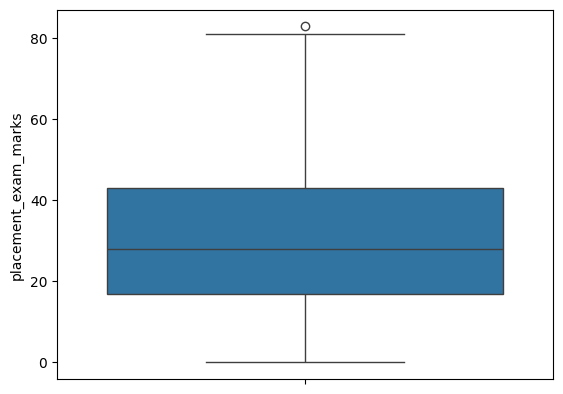

In [ ]:
sbn.boxplot(df_quantile['placement_exam_marks'])     #-23.5  -  84.5

<ipython-input-112-5abd65a2ee7f>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(df_2['placement_exam_marks'])
<ipython-input-112-5abd65a2ee7f>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(df_quantile['placement_exam_marks'])


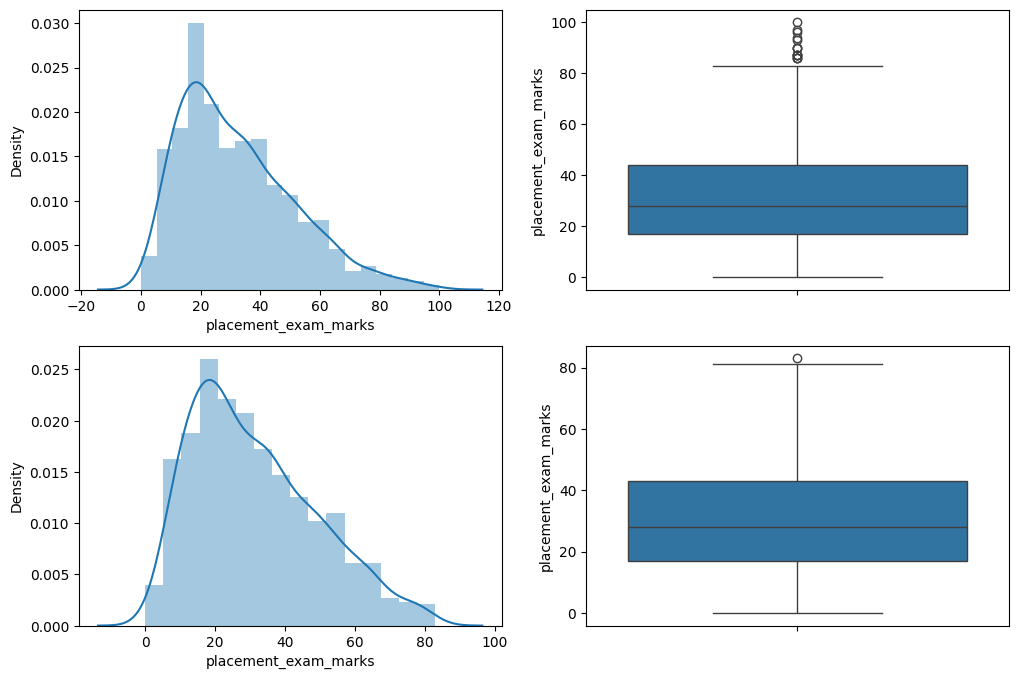

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sbn.distplot(df_2['placement_exam_marks'])

plt.subplot(2,2,2)
sbn.boxplot(df_2['placement_exam_marks'])

plt.subplot(2,2,3)
sbn.distplot(df_quantile['placement_exam_marks'])

plt.subplot(2,2,4)
sbn.boxplot(df_quantile['placement_exam_marks'])

plt.show()

In [ ]:
#capping

df_2_cap = df_2.copy()
df_2_cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [ ]:
q1 = df_2_cap['placement_exam_marks'].quantile(0.25)
q3 = df_2_cap['placement_exam_marks'].quantile(0.75)
iqr = q3-q1

In [ ]:
max_range = q3+1.5*iqr    #84.5
min_range = q1-1.5*iqr    #-23.5


-23.5

In [ ]:
df_2_cap['placement_exam_marks'] = np.where(df_2_cap['placement_exam_marks']>max_range,max_range,(np.where(df_2_cap['placement_exam_marks']<min_range,min_range,df_2_cap['placement_exam_marks'])))
df_2_cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [ ]:
df_2_cap.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.136500,0.489000
std,0.615898,18.865419,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,84.500000,1.000000


<ipython-input-124-bb954891161c>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(df_2['placement_exam_marks'])
<ipython-input-124-bb954891161c>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sbn.distplot(df_2_cap['placement_exam_marks'])


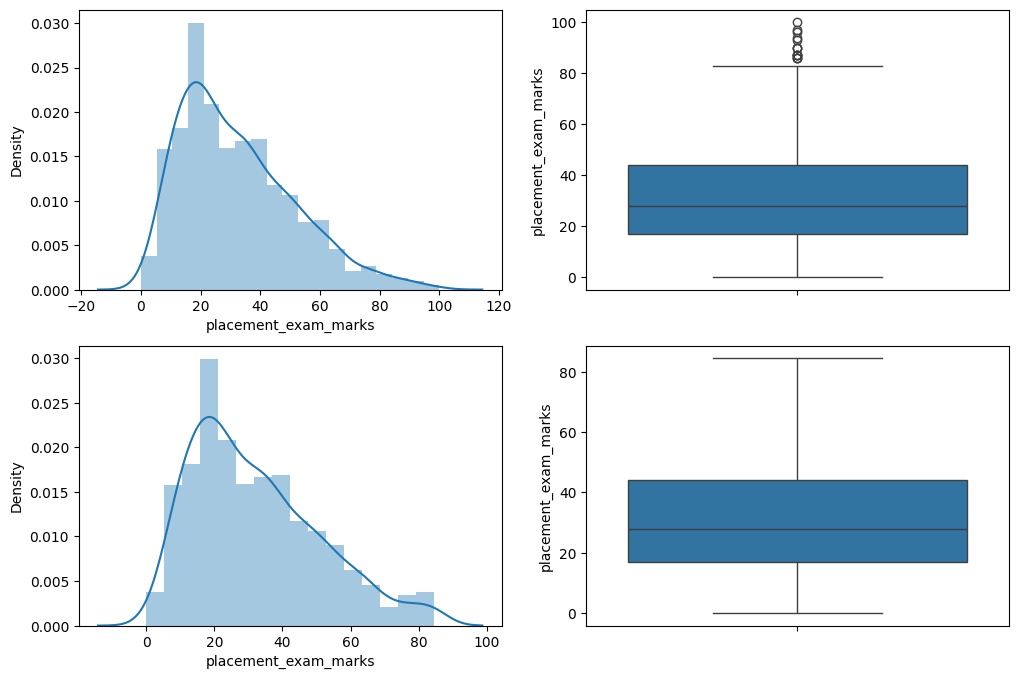

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sbn.distplot(df_2['placement_exam_marks'])

plt.subplot(2,2,2)
sbn.boxplot(df_2['placement_exam_marks'])

plt.subplot(2,2,3)
sbn.distplot(df_2_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sbn.boxplot(df_2_cap['placement_exam_marks'])

plt.show()